In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, FloatSlider, SelectionSlider
import os
from tqdm import tqdm

---

In [45]:
# folder = 'test_fixed_bc_20260331_152300'  # Change this to your actual folder name
# folder = 'double_well_test_20260425_144214'
# folder = 'parabolic_mobility_test_20260427_174052'

# folder = 'data/test_droplet_20260915_175728'
folder = 'data/test_droplet_full_impl_20260917_132412'

In [ ]:
# ============================================================
# 2D Heatmap Visualization for Perlin Noise Solution
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown, Play, jslink
import os
import glob

def load_solution(filename):
    """Load solution from binary file saved by C++ code."""
    with open(filename, 'rb') as f:
        dims = np.frombuffer(f.read(12), dtype=np.int32)
        n_components = np.frombuffer(f.read(4), dtype=np.int32)[0]
        data = np.frombuffer(f.read(), dtype=np.float64)
        data = data.reshape((dims[2], dims[1], dims[0], n_components))
        # Transpose to (N, N, N, 2) with x as first axis
        data = np.transpose(data, (2, 1, 0, 3))
    return data, dims[0]

# Update this folder name to match your Perlin noise run
folder_path = f'../{folder}'

# Check for time-dependent solutions (numerical_0.bin, numerical_1.bin, ...)
numerical_files = sorted(glob.glob(f'{folder_path}/numerical_*.bin'),
                         key=lambda x: int(x.split('_')[-1].split('.')[0]))
if len(numerical_files) == 0:
    # Time-independent case: single numerical.bin file
    numerical_files = [f'{folder_path}/numerical.bin']
    if not os.path.exists(numerical_files[0]):
        raise FileNotFoundError(f"Could not find numerical solution file in {folder_path}")

# Load all numerical solutions
numerical_solutions = []
for filename in tqdm(numerical_files):
    data, N = load_solution(filename)
    numerical_solutions.append(data)

# Convert to numpy array: shape will be (num_frames, N, N, N, 2) for time-dependent
# or (1, N, N, N, 2) for time-independent
# Note: index 0 is initial approximation, index 1+ are solutions after time steps
numerical = np.array(numerical_solutions)
num_frames = len(numerical_solutions)

# Ensure numerical always has 5 dimensions (frames, N, N, N, components)
if numerical.ndim == 4:
    numerical = numerical[np.newaxis, ...]  # Add time dimension if missing
    num_frames = 1

print(f"Loaded solutions with grid size N = {N}")
print(f"Number of frames: {num_frames} (index 0 = initial approximation, 1-{num_frames-1} = after time steps)")
print(f"Solution shape: {numerical.shape}")
print(f"Components: [psi, phi]")

# Calculate cell-centered coordinate values: h*(0.5 + i) for i = 0, 1, ..., N-1
h = 1.0 / N
cell_centered_coords = np.array([h * (0.5 + i) for i in range(N)])

# Precompute global min/max for consistent colorbar scaling across all frames
vmin_global = {}
vmax_global = {}
for comp in [0, 1]:
    vmin_global[comp] = numerical[:,:,:,:,comp].min()
    vmax_global[comp] = numerical[:,:,:,:,comp].max()

def plot_2d_heatmap(frame_idx=0, slice_axis=0, layer_idx=16, component=1):
    """
    2D heatmap visualization of solution slice.

    frame_idx: frame index (0 = initial approximation, 1+ = after time steps)
    slice_axis: 0=x, 1=y, 2=z (axis perpendicular to the slice plane)
    layer_idx: index of the layer along slice_axis (0 to N-1)
    component: 0=psi, 1=phi
    """
    axis_names = ['x', 'y', 'z']
    component_names = ['ψ (psi)', 'φ (phi)']

    # Get numerical solution for the selected frame
    numerical_frame = numerical[frame_idx]

    # Extract 2D slice based on slice_axis and layer_idx
    if slice_axis == 0:  # Slice along x-axis: show y-z plane
        slice_data = numerical_frame[layer_idx, :, :, component]
        x_coords = cell_centered_coords  # y coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'y'
        ylabel = 'z'
        title_axis = f'x = {cell_centered_coords[layer_idx]:.4f}'
    elif slice_axis == 1:  # Slice along y-axis: show x-z plane
        slice_data = numerical_frame[:, layer_idx, :, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # z coordinates
        xlabel = 'x'
        ylabel = 'z'
        title_axis = f'y = {cell_centered_coords[layer_idx]:.4f}'
    else:  # slice_axis == 2, Slice along z-axis: show x-y plane
        slice_data = numerical_frame[:, :, layer_idx, component]
        x_coords = cell_centered_coords  # x coordinates
        y_coords = cell_centered_coords  # y coordinates
        xlabel = 'x'
        ylabel = 'y'
        title_axis = f'z = {cell_centered_coords[layer_idx]:.4f}'

    # Plot with imshow (no interpolation, pixelated)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(
        slice_data.T,                       # Transpose so that axes match: y first, then x
        origin='lower',
        aspect='equal',
        cmap='viridis',
        extent=[x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]],
        vmin=vmin_global[component],
        vmax=vmax_global[component],
        interpolation='none'
    )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(component_names[component], fontsize=14)

    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # Title
    title = f'Cahn-Hilliard: {component_names[component]} slice at {title_axis}'
    if num_frames > 1:
        if frame_idx == 0:
            title += ', Initial approximation'
        else:
            title += f', After iteration {frame_idx}'
    ax.set_title(title, fontsize=14)

    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Create frame slider: if only one frame, slider has single value 0
if num_frames > 1:
    frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='Frame:')
else:
    frame_slider = IntSlider(min=0, max=0, value=0, description='Frame:', disabled=True)

# Create layer slider (stays fully manual)
layer_slider = IntSlider(min=0, max=N-1, value=N//2, description='Layer:', )

# Optional auto-iteration over frames only.
# Layer remains under manual control.
from IPython.display import display

if num_frames > 1:
    frame_play = Play(
        value=int(frame_slider.value),
        min=0,
        max=num_frames-1,
        step=1,
        interval=150,  # ms between frames (reduce if you want faster)
        description='Auto Frame',
    )

    a_sync = {'on': False}

    def _play_to_frame(change):
        if a_sync['on']:
            return
        a_sync['on'] = True
        frame_slider.value = int(change['new'])
        a_sync['on'] = False

    def _frame_to_play(change):
        if a_sync['on']:
            return
        a_sync['on'] = True
        frame_play.value = int(change['new'])
        a_sync['on'] = False

    frame_play.observe(_play_to_frame, names='value')
    frame_slider.observe(_frame_to_play, names='value')

    display(frame_play)

interact(
    plot_2d_heatmap,
    frame_idx=frame_slider,
    slice_axis=Dropdown(
        options=[('x (show y-z plane)', 0), ('y (show x-z plane)', 1), ('z (show x-y plane)', 2)],
        value=0,
        description='Slice axis:'
    ),
    layer_idx=layer_slider,
    component=Dropdown(
        options=[('ψ (psi)', 0), ('φ (phi)', 1)],
        value=1,
        description='Field:',
    ),
)
plt.show()

100%|██████████| 101/101 [00:00<00:00, 1030.06it/s]


Loaded solutions with grid size N = 64
Number of frames: 101 (index 0 = initial approximation, 1-100 = after time steps)
Solution shape: (101, 64, 64, 64, 2)
Components: [psi, phi]


Play(value=0, description='Auto Frame', interval=150)

interactive(children=(IntSlider(value=0, description='Frame:'), Dropdown(description='Slice axis:', options=((…

In [47]:
log_file = f'../{folder}/log.txt'

acc_dt_inf = []

cumm_psi = []
cumm_phi = []

phobic_energies = []
philic_energies = []

with open(log_file, "r") as log_f:
    line = '1'
    while line:
        line = log_f.readline()

        if 'Accepted dt_inf' in line:
            acc_dt_inf.append(float(line.strip().split(':')[2]))
        elif 'Component sums @ step' in line:
            psi, phi = map(float, line.strip().split(':')[2].split(','))
            cumm_psi.append(psi)
            cumm_phi.append(phi)
        elif 'Phobic energy' in line:
            phobic_energies.append(float(line.strip().split(':')[2]))
        elif 'Philic energy' in line:
            philic_energies.append(float(line.strip().split(':')[2]))

print('acc_dt_inf:', len(acc_dt_inf))
print('cumm_psi:', len(cumm_psi))
print('cumm_phi:', len(cumm_phi))
print('phobic_energies:', len(phobic_energies))
print('philic_energies:', len(philic_energies))


acc_dt_inf: 100
cumm_psi: 100
cumm_phi: 100
phobic_energies: 101
philic_energies: 101


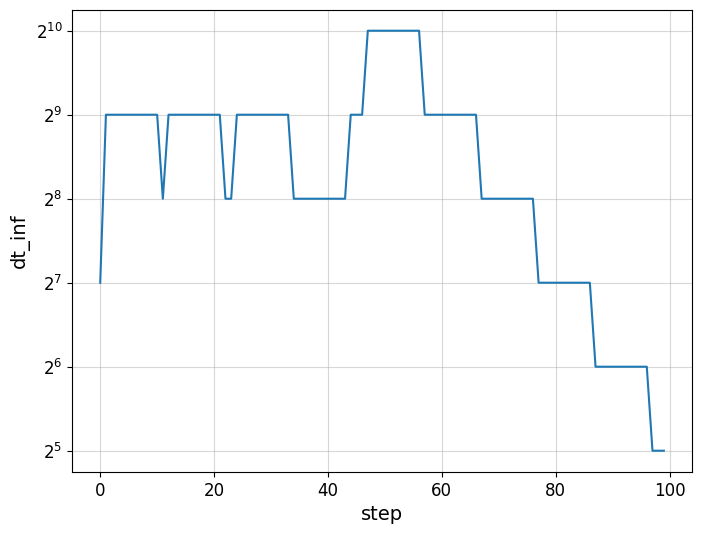

In [48]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

steps = np.arange(len(acc_dt_inf))
plt.plot(steps, acc_dt_inf)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log', base=2)
plt.xlabel('step', fontsize=14)
plt.ylabel('dt_inf', fontsize=14)

plt.savefig(f'../{folder}/dt_inf.png', dpi=150)
plt.show()

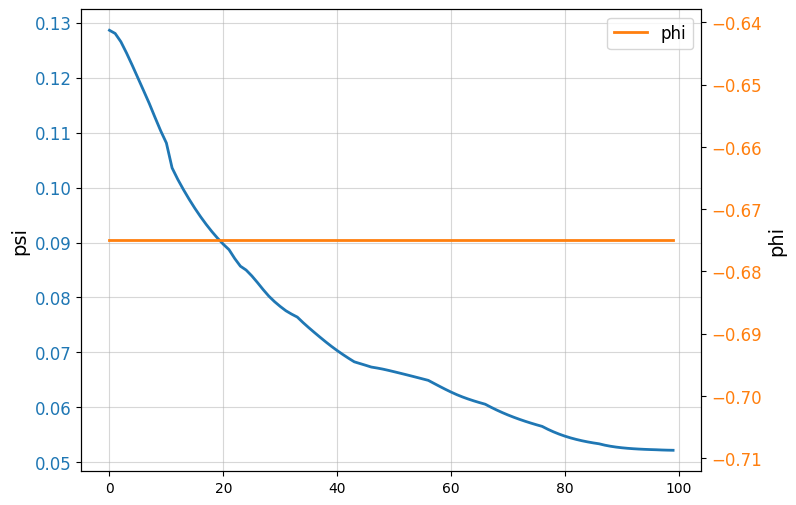

In [49]:
fig, ax1 = plt.subplots(figsize=(8, 6))
plt.grid(alpha=0.5)

steps = np.arange(len(cumm_psi))
ax1.plot(steps, cumm_psi, lw=2, color='C0', label='psi')
ax2 = ax1.twinx()
ax2.plot(steps, cumm_phi, lw=2, color='C1', label='phi')

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
ax1.tick_params(axis='y', labelcolor='C0', labelsize=12)  # Цвет меток на первой оси
ax2.tick_params(axis='y', labelcolor='C1', labelsize=12)  # Цвет меток на второй оси
# plt.yscale('log', base=2)
plt.xlabel('step', fontsize=14)
ax1.set_ylabel('psi', fontsize=14)
ax2.set_ylabel('phi', fontsize=14)

plt.savefig(f'../{folder}/psi_phi.png', dpi=150)
plt.show()

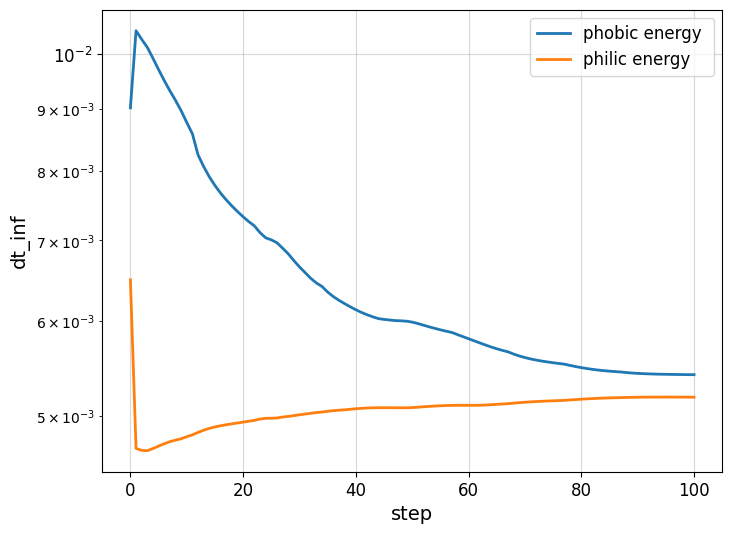

In [50]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

steps = np.arange(len(phobic_energies))
plt.plot(steps, phobic_energies, lw=2, label='phobic energy ')
plt.plot(steps, philic_energies, lw=2, label='philic energy')

plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xlabel('step', fontsize=14)
plt.ylabel('dt_inf', fontsize=14)

plt.savefig(f'../{folder}/phobic_philic.png', dpi=150)
plt.show()